# Objectifs d'apprentissage – Semaine 6

À l'issue de cette semaine, l'étudiant sera capable de :

- **Comprendre** le passage du domaine temporel au domaine fréquentiel.
- **Définir** les séries de Fourier pour les signaux périodiques.
- **Appliquer** la transformée de Fourier à temps discret (DTFT) pour l'analyse spectrale.
- **Interpréter** un spectre de fréquences (amplitude, phase).
- **Visualiser** le spectre d'un signal à l'aide de la FFT.
- **Analyser** l'effet du fenêtrage sur la résolution spectrale.
- **Utiliser** Python pour effectuer des analyses spectrales sur des signaux réels (audio, synthétiques).

# 1. Rappels théoriques

## 1.1 Séries de Fourier

Tout signal périodique $x(t)$ de période $T$ peut être décomposé en une somme de sinus et cosinus (ou d'exponentielles complexes) :

$$ x(t) = \sum_{k=-\infty}^{\infty} c_k e^{j k \omega_0 t} $$

avec $\omega_0 = 2\pi/T$ et
$$ c_k = \frac{1}{T} \int_{T} x(t) e^{-j k \omega_0 t} dt $$

## 1.2 Transformée de Fourier à temps discret (DTFT)

Pour une séquence $x[n]$, la DTFT est définie par :
$$ X(e^{j\omega}) = \sum_{n=-\infty}^{\infty} x[n] e^{-j\omega n} $$

Propriétés :
- Périodicité : $X(e^{j(\omega+2\pi)}) = X(e^{j\omega})$
- Transformée inverse : $x[n] = \frac{1}{2\pi} \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega$

## 1.3 Spectre de fréquence

Le spectre d'un signal est la représentation de son contenu fréquentiel :
- **Spectre d'amplitude** : $|X(e^{j\omega})|$
- **Spectre de phase** : $\arg X(e^{j\omega})$

## 1.4 Fenêtrage

En pratique, on analyse des signaux de durée finie. L'application d'une fenêtre (Hamming, Hanning, Blackman) permet de réduire les fuites spectrales (leakage) au prix d'une résolution légèrement dégradée.

---

# 2. Démonstrations Python

## 2.1 Synthèse de Fourier – Signal carré

Nous allons synthétiser un signal carré à partir de ses harmoniques.

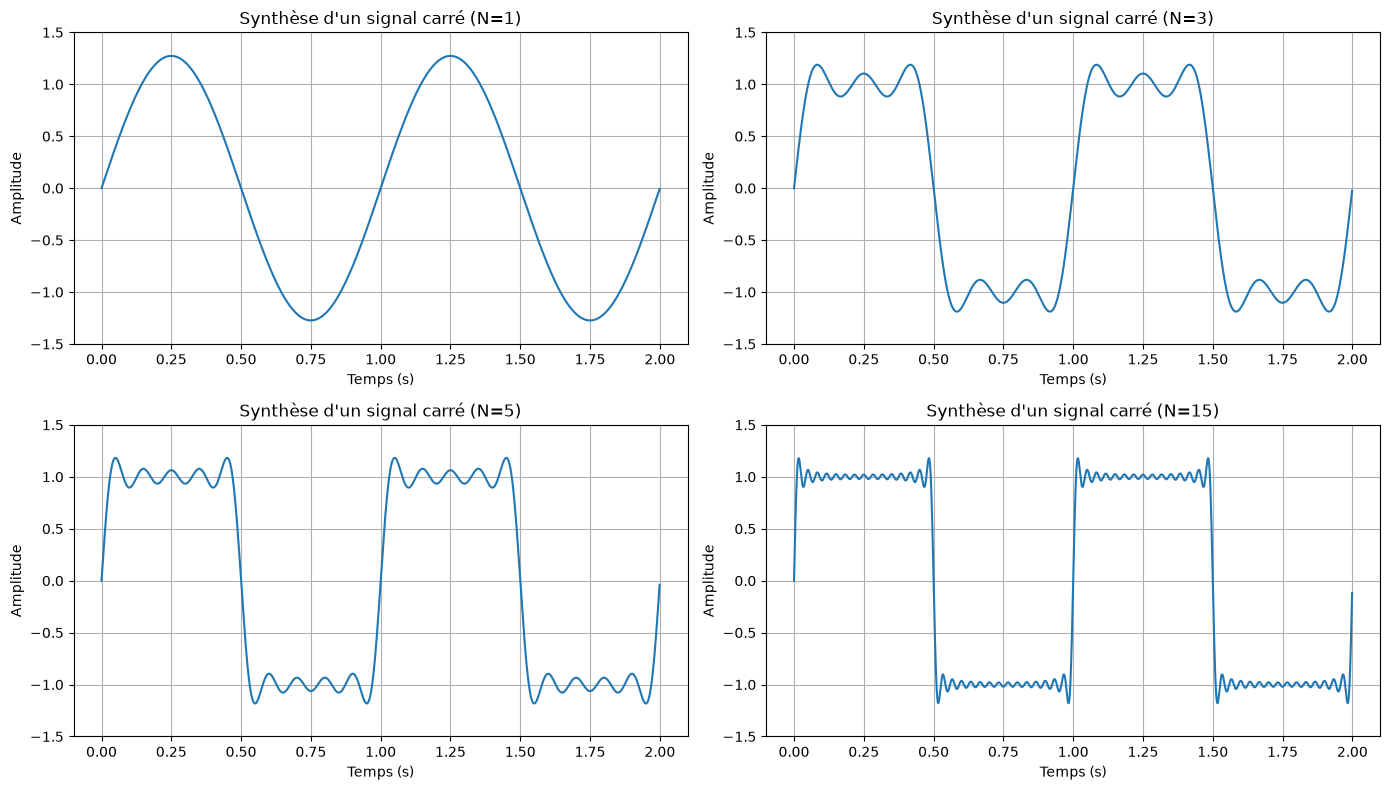

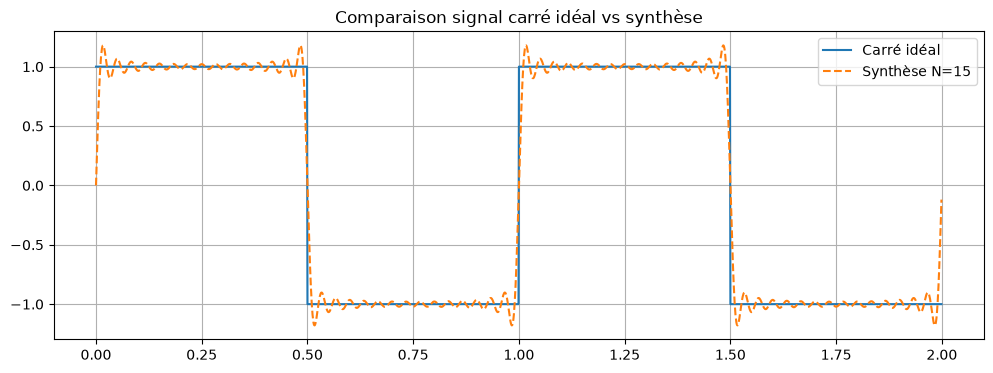

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Paramètres
f0 = 1  # fréquence fondamentale (Hz)
T = 1/f0
fs = 1000  # fréquence d'échantillonnage
t = np.linspace(0, 2*T, int(2*T*fs), endpoint=False)

def square_synthesis(t, f0, N_harmonics):
    """Synthèse d'un signal carré par série de Fourier."""
    x = np.zeros_like(t)
    for k in range(1, N_harmonics*2, 2):  # harmoniques impaires seulement
        x += (4 / (np.pi * k)) * np.sin(2*np.pi*k*f0*t)
    return x

# Tracer pour différents nombres d'harmoniques
plt.figure(figsize=(14, 8))
for i, N in enumerate([1, 3, 5, 15]):
    x = square_synthesis(t, f0, N)
    plt.subplot(2, 2, i+1)
    plt.plot(t, x, label=f'N={N} harmoniques')
    plt.xlabel('Temps (s)')
    plt.ylabel('Amplitude')
    plt.title(f'Synthèse d\'un signal carré (N={N})')
    plt.grid()
    plt.ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

# Comparaison avec la fonction square de scipy.signal
from scipy import signal
x_ref = signal.square(2*np.pi*f0*t)
x_15 = square_synthesis(t, f0, 15)
plt.figure(figsize=(12, 4))
plt.plot(t, x_ref, label='Carré idéal')
plt.plot(t, x_15, '--', label='Synthèse N=15')
plt.legend()
plt.grid()
plt.title('Comparaison signal carré idéal vs synthèse')
plt.show()

## 2.2 DTFT et FFT

La FFT (Fast Fourier Transform) est un algorithme efficace pour calculer la DFT (Discrete Fourier Transform), qui est une version échantillonnée de la DTFT.

In [ ]:
# Générer un signal composé de deux sinusoïdes
fs = 200  # Hz
N = 128   # nombre d'échantillons
t = np.arange(N) / fs

f1, f2 = 10, 30  # Hz
x = np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t)

# FFT
X = fft(x)
freqs = fftfreq(N, 1/fs)

# Tracé du spectre (seulement les fréquences positives)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(t, x)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Signal temporel')
plt.grid()

plt.subplot(1, 2, 2)
plt.stem(freqs[:N//2], np.abs(X[:N//2]) / N, basefmt=' ')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Magnitude')
plt.title('Spectre d\'amplitude (FFT)')
plt.grid()
plt.xlim(0, 50)
plt.show()

print(f"Fréquences détectées : {f1} Hz et {f2} Hz.")

## 2.3 Effet du fenêtrage

Comparons le spectre d'un signal avec et sans fenêtre de Hamming.

In [ ]:
# Signal composé de deux fréquences proches
fs = 200
N = 64
t = np.arange(N) / fs
f1, f2 = 10, 12
x = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)

# Fenêtre de Hamming
window = np.hamming(N)
x_windowed = x * window

# FFT des deux signaux
X = fft(x)
Xw = fft(x_windowed)
freqs = fftfreq(N, 1/fs)[:N//2]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.stem(freqs, np.abs(X[:N//2]) / N, basefmt=' ')
plt.title('Spectre sans fenêtrage')
plt.xlabel('Fréquence (Hz)')
plt.xlim(5, 17)
plt.grid()

plt.subplot(1, 2, 2)
plt.stem(freqs, np.abs(Xw[:N//2]) / N, basefmt=' ')
plt.title('Spectre avec fenêtre de Hamming')
plt.xlabel('Fréquence (Hz)')
plt.xlim(5, 17)
plt.grid()
plt.show()

print("Le fenêtrage réduit les fuites spectrales (lobes secondaires), mais élargit légèrement les pics.")

## 2.4 Analyse spectrale d'un signal audio (synthétique)

Créons un signal audio synthétique (par exemple une note de musique) et analysons son spectre.

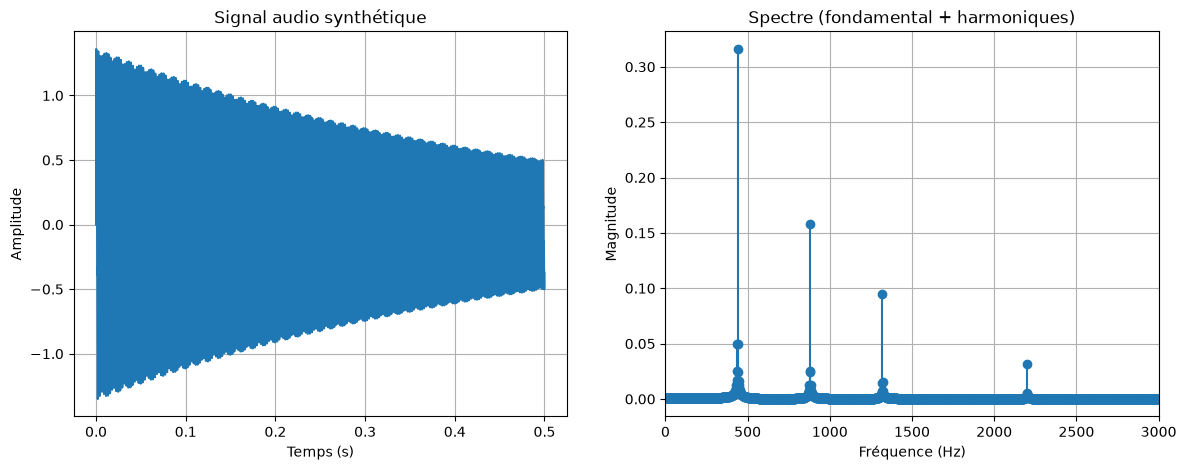

Fondamental à 440 Hz, harmoniques à 880, 1320, 2200 Hz.


In [2]:
# Génération d'une note de musique (La 440 Hz + harmoniques)
fs = 8000
duration = 0.5  # secondes
t = np.linspace(0, duration, int(fs*duration), endpoint=False)
f_fond = 440  # La4

# Fondamental + 3 harmoniques
x = (np.sin(2*np.pi*f_fond*t) +
     0.5*np.sin(2*np.pi*2*f_fond*t) +
     0.3*np.sin(2*np.pi*3*f_fond*t) +
     0.1*np.sin(2*np.pi*5*f_fond*t))

# Enveloppe d'extinction
envelope = np.exp(-2*t)  # décroissance exponentielle
x = x * envelope

# FFT
N = len(x)
X = fft(x)
freqs = fftfreq(N, 1/fs)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(t, x)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Signal audio synthétique')
plt.grid()

plt.subplot(1, 2, 2)
plt.stem(freqs[:N//2], np.abs(X[:N//2]) / N, basefmt=' ')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Magnitude')
plt.title('Spectre (fondamental + harmoniques)')
plt.xlim(0, 3000)
plt.grid()
plt.show()

print("Fondamental à 440 Hz, harmoniques à 880, 1320, 2200 Hz.")

# 3. Exercices – Semaine 6

## Exercice 1 – Synthèse de Fourier

1. Synthétiser un signal triangulaire à l'aide de sa série de Fourier (harmoniques impaires, coefficients en $1/k^2$).
2. Comparer avec la fonction `signal.sawtooth` de scipy (avec `width=0.5`).
3. Observer l'effet du nombre d'harmoniques sur la qualité de la reconstruction.

**Code** :

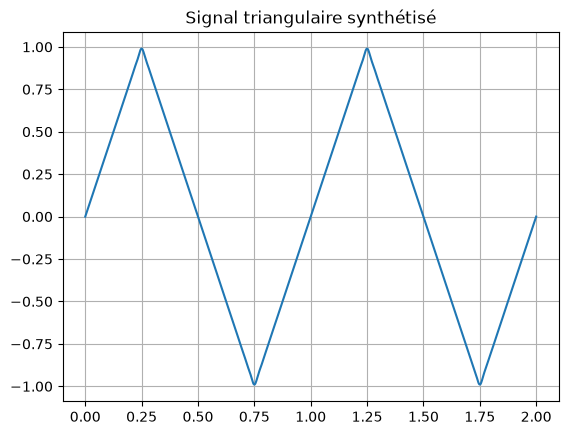

In [3]:
# À compléter
def triangle_synthesis(t, f0, N_harmonics):
    """Synthèse d'un signal triangulaire."""
    # Les coefficients pour un signal triangulaire sont : 8/(pi^2) * (-1)^((k-1)/2) / k^2
    # pour k impair
    x = np.zeros_like(t)
    for k in range(1, N_harmonics*2, 2):
        coef = 8 / (np.pi**2 * k**2) * (-1)**((k-1)//2)
        x += coef * np.sin(2*np.pi*k*f0*t)
    return x

# Test
f0 = 1
t = np.linspace(0, 2, 1000)
x = triangle_synthesis(t, f0, 20)
plt.plot(t, x)
plt.grid()
plt.title('Signal triangulaire synthétisé')
plt.show()

## Exercice 2 – DTFT et FFT

1. Générer un signal $x[n] = (0.9)^n u[n]$ pour $n=0,\dots,50$.
2. Calculer sa DTFT de manière approchée en utilisant la FFT avec un zero-padding (par exemple N_fft=1024).
3. Comparer avec la formule théorique $X(e^{j\omega}) = 1 / (1 - 0.9 e^{-j\omega})$.
4. Tracer le module de la DTFT pour $\omega \in [0, \pi]$.

**Code** :

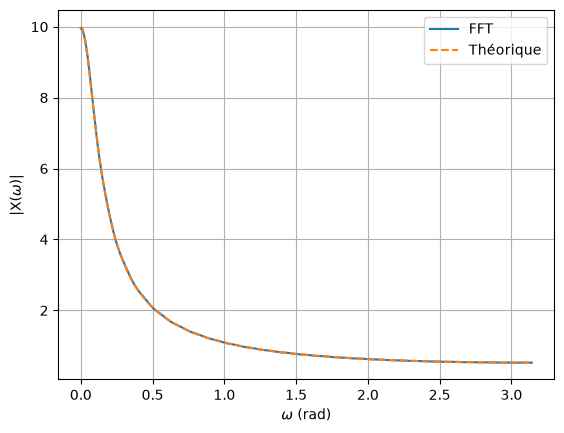

In [7]:
n = np.arange(50)
x = (0.9)**n

N_fft = 1024
X = fft(x, N_fft)
freqs = np.linspace(0, np.pi, N_fft//2)

# Théorique
X_theo = 1 / (1 - 0.9 * np.exp(-1j*freqs))

plt.plot(freqs, np.abs(X[:N_fft//2]), label='FFT')
plt.plot(freqs, np.abs(X_theo), '--', label='Théorique')
plt.xlabel('$\\omega$ (rad)')
plt.ylabel('|X($\\omega$)|')
plt.legend()
plt.grid()
plt.show()

## Exercice 3 – Spectre et fenêtrage

Soit $x[n] = \cos(0.4\pi n) + \cos(0.45\pi n)$ pour $n=0,\dots,31$.

1. Calculer et tracer le spectre (FFT) sans fenêtre.
2. Appliquer une fenêtre de Hamming et tracer le spectre.
3. Comparer la résolution et le niveau des lobes secondaires.
4. Que se passe-t-il si on augmente la durée (N=128) ?

**Code** :

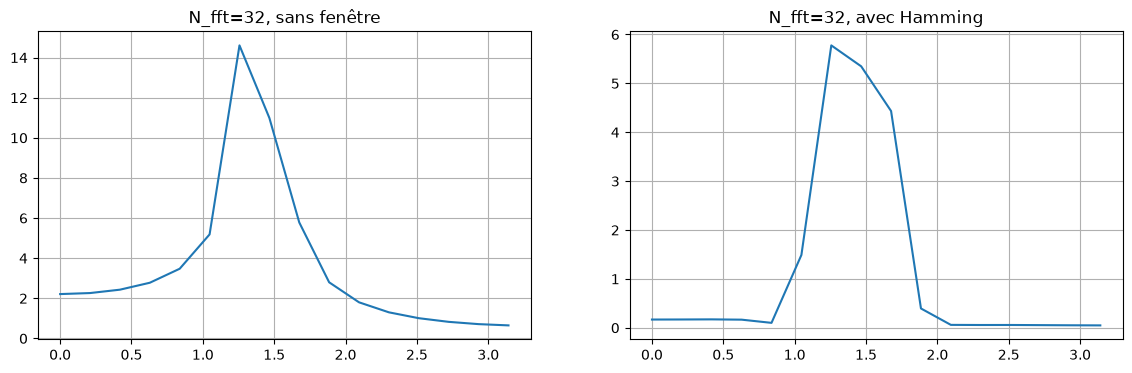

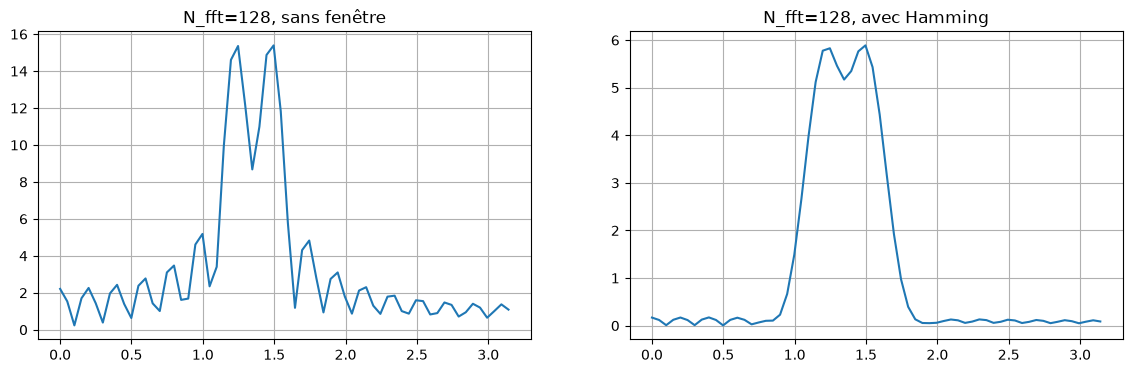

In [5]:
N = 32
n = np.arange(N)
x = np.cos(0.4*np.pi*n) + np.cos(0.45*np.pi*n)

for N_fft in [32, 128]:
    X = fft(x, N_fft)
    Xw = fft(x * np.hamming(N), N_fft)
    freqs = np.linspace(0, np.pi, N_fft//2)
    
    plt.figure(figsize=(14, 4))
    plt.subplot(1, 2, 1)
    plt.plot(freqs, np.abs(X[:N_fft//2]), label='Sans fenêtre')
    plt.title(f'N_fft={N_fft}, sans fenêtre')
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.plot(freqs, np.abs(Xw[:N_fft//2]), label='Avec Hamming')
    plt.title(f'N_fft={N_fft}, avec Hamming')
    plt.grid()
    plt.show()

## Exercice 4 – Analyse spectrale d'un fichier audio

1. Charger un fichier audio (WAV) à l'aide de `scipy.io.wavfile.read` ou générer un signal de test.
2. Calculer et tracer le spectrogramme (évolution du spectre dans le temps) avec `matplotlib.pyplot.specgram` ou `scipy.signal.spectrogram`.
3. Identifier les composantes fréquentielles présentes.

**Code** :

In [ ]:
from scipy import signal

# Générer un signal avec des fréquences variables (chirp)
fs = 1000
t = np.linspace(0, 2, 2000)
x = np.sin(2*np.pi * (50 + 100*t) * t)  # fréquence croissante

# Spectrogramme
f, t_spec, Sxx = signal.spectrogram(x, fs, nperseg=256, noverlap=128)
plt.pcolormesh(t_spec, f, 10*np.log10(Sxx), shading='gouraud')
plt.ylabel('Fréquence (Hz)')
plt.xlabel('Temps (s)')
plt.colorbar(label='Intensité (dB)')
plt.title('Spectrogramme')
plt.show()

## Exercice 5 – Spectre de phase

1. Générer un signal $x[n] = \cos(0.3\pi n + \pi/4)$.
2. Calculer la FFT et tracer le spectre de phase.
3. Identifier la phase à la fréquence du signal.
4. Que devient la phase si on décale le signal dans le temps ?

**Code** :

In [ ]:
N = 64
n = np.arange(N)
phi = np.pi/4
x = np.cos(0.3*np.pi*n + phi)

X = fft(x)
freqs = np.fft.fftfreq(N)[:N//2]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.stem(freqs, np.abs(X[:N//2]), basefmt=' ')
plt.title('Spectre d\'amplitude')
plt.grid()

plt.subplot(1, 2, 2)
plt.stem(freqs, np.angle(X[:N//2]), basefmt=' ')
plt.title('Spectre de phase')
plt.grid()
plt.show()

print("Phase à la fréquence du signal (0.3π) :", np.angle(X[10]))

## Exercice 6 – Analyse spectrale de signaux réels (ECG, audio)

1. Charger un signal ECG (par exemple depuis un fichier CSV).
2. Analyser son spectre pour identifier les fréquences cardiaques (battement, harmoniques).
3. Appliquer un filtrage passe-bande pour isoler la composante cardiaque.

**Code** (à adapter selon les données disponibles) :

In [ ]:
# Exemple avec un signal synthétique
fs = 250  # Hz
t = np.linspace(0, 10, 2500)
# Simulation d'un ECG simplifié : impulsion périodique
x = np.zeros_like(t)
for i in range(0, len(t), 250):  # battement à 1 Hz
    x[i:i+20] = 1
x = x + 0.1*np.random.randn(len(x))

X = fft(x)
freqs = fftfreq(len(x), 1/fs)[:len(x)//2]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(t, x)
plt.title('Signal ECG synthétique')
plt.xlabel('Temps (s)')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(freqs, np.abs(X[:len(x)//2]) / len(x))
plt.xlim(0, 10)
plt.title('Spectre (pic à 1 Hz)')
plt.xlabel('Fréquence (Hz)')
plt.grid()
plt.show()

# 4. Livrable Semaine 6

- Remplir les cellules de code avec vos solutions.
- Répondre aux questions théoriques dans les cellules markdown.
- Inclure des commentaires explicatifs.
- Rendre le notebook complet (cellules exécutées).

**Date de rendu** : à définir par l'enseignant.

---